# 科学建模方法论 (模型诊断与数据规范)

## 课程导论
本节课将聚焦于机器学习工程实践中的核心方法论，探讨数据分布的特征缩放（Feature Scaling）机制、数据集的严格划分范式，以及如何通过损失函数曲线进行模型状态诊断，从而有效评估并应对过拟合（Overfitting）与欠拟合（Underfitting）问题。

---

## 第一部分：数据预处理法则 —— 特征缩放的作用与原理

在多维特征空间中，不同物理变量的数据量级（Scale）往往存在显著差异。

### 1. 量纲差异对优化的负面影响
若未经处理直接将原始数据输入模型，数值绝对值较大的特征将主导梯度更新的方向。在几何直觉上，这会导致目标函数的等高线呈现高度椭圆化（狭长分布），使得梯度下降算法在优化路径上产生剧烈振荡，极大地降低收敛速率，甚至导致模型陷入局部最优。

### 2. 标准化 (Standardization / Z-Score)
标准化的核心目的在于消除量纲影响，将数据映射为**均值为 0、标准差为 1** 的标准正态分布，使特征空间具有各向同性（Isotropy），从而加速梯度下降的收敛过程。它对离群点（Outliers）具有较好的鲁棒性。
$$X_{scaled} = \frac{X - \mu}{\sigma}$$
* $\mu$：该特征在样本空间中的经验期望（均值）。
* $\sigma$：该特征在样本空间中的经验标准差。

### 3. 归一化 (Normalization / Min-Max Scaling)
归一化是另一种常用的线性缩放手段，其核心目的是将数据严格映射到特定的有界区间内（通常为 **[0, 1]** 或 **[-1, 1]**）。常用于图像像素处理（如 0~255 映射到 0~1）或当网络拓扑需要特定激活函数（如 Sigmoid 输出域）配合时。
$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$
* $X_{min}$：该特征在当前样本空间中的极小值。
* $X_{max}$：该特征在当前样本空间中的极大值。
* **工程缺陷**：归一化对极端异常值（Outliers）极度敏感。如果存在一个极大的错误数据，会导致其他所有正常数据被严重压缩到一个极窄的区间内。

### 4. 工程师的选型指南
* 优先使用 **标准化 (Z-Score)**：几乎是全连接网络、卷积神经网络（CNN）的默认选择。
* 必须使用 **归一化 (Min-Max)**：明确知道物理边界的数据（如图像 RGB 值），或作为生成对抗网络（GAN）的输入/输出映射。

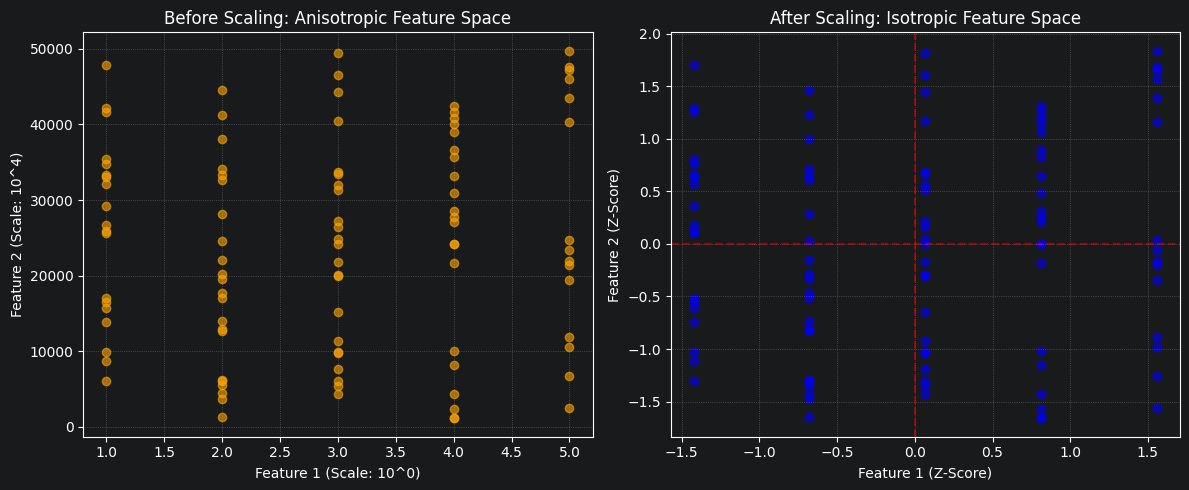

标准化后，特征 1 的统计参数 -> 均值: -0.0000, 标准差: 1.0000
标准化后，特征 2 的统计参数 -> 均值: -0.0000, 标准差: 1.0000


In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. 构建存在显著量纲差异的多维特征数据
rooms = torch.randint(1, 6, (100, 1), dtype=torch.float32)               # 特征 1：数量级 10^0
distance = torch.randint(1000, 50000, (100, 1), dtype=torch.float32)     # 特征 2：数量级 10^4
X_raw = torch.cat([rooms, distance], dim=1)

# 2. 实施 Z-Score 标准化
X_mean = X_raw.mean(dim=0)
X_std = X_raw.std(dim=0)
X_scaled = (X_raw - X_mean) / X_std

# 3. 特征空间拓扑结构可视化对比
plt.figure(figsize=(12, 5))

# 归一化前：各向异性空间 (Anisotropic Space)
plt.subplot(1, 2, 1)
plt.scatter(X_raw[:, 0].numpy(), X_raw[:, 1].numpy(), color='orange', alpha=0.6)
plt.title("Before Scaling: Anisotropic Feature Space")
plt.xlabel("Feature 1 (Scale: 10^0)")
plt.ylabel("Feature 2 (Scale: 10^4)")
plt.grid(True, linestyle=':')

# 归一化后：各向同性空间 (Isotropic Space)
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0].numpy(), X_scaled[:, 1].numpy(), color='blue', alpha=0.6)
plt.title("After Scaling: Isotropic Feature Space")
plt.xlabel("Feature 1 (Z-Score)")
plt.ylabel("Feature 2 (Z-Score)")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

print(f"标准化后，特征 1 的统计参数 -> 均值: {X_scaled[:, 0].mean().item():.4f}, 标准差: {X_scaled[:, 0].std().item():.4f}")
print(f"标准化后，特征 2 的统计参数 -> 均值: {X_scaled[:, 1].mean().item():.4f}, 标准差: {X_scaled[:, 1].std().item():.4f}")

## 第二部分：数据集划分范式与信息泄漏防范

在机器学习任务中，评估模型对未见数据的泛化能力（Generalization Ability）是核心目标。为此，必须建立严格的数据隔离机制。

### 1. 数据的三方划分原则
* **训练集（Training Set）**：用于模型参数（Weights & Biases）的迭代更新与经验风险最小化。
* **验证集（Validation Set）**：用于超参数（Hyperparameters）调优与模型结构选择，是监控模型训练状态的核心基准。
* **测试集（Test Set）**：用于最终无偏地评估模型的真实泛化性能。在模型开发的全周期内，测试集必须保持绝对的不可见性。

### 2. 数据泄漏（Data Leakage）的危害与规避
**学术红线**：若在数据集划分前，即利用全局数据进行统计量（如均值、方差）的计算，将导致测试集的分布特征提前暴露给训练过程，造成评估指标严重失真（虚高）。
**规范流程**：必须**先**执行数据切分，**后**进行特征缩放。验证集与测试集的标准化，必须且只能依赖于训练集独立计算得出的统计参数 $\mu$ 和 $\sigma$。

In [7]:
from sklearn.model_selection import train_test_split

# 设定初始总体样本池
X_all = torch.randn(1000, 5)
y_all = torch.randn(1000, 1)

print(f"总体样本容量: {len(X_all)}")

# 1. 数据集隔离：优先划分出无偏测试集 (Test Set)
X_temp, X_test, y_temp, y_test = train_test_split(X_all, y_all, test_size=0.15, random_state=42)

# 2. 内部划分：将剩余数据划分为训练集 (Train) 与验证集 (Validation)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/0.85, random_state=42)

print("\n--- 科学数据切分验证 ---")
print(f"训练集容量 (Training Set):   {len(X_train)}")
print(f"验证集容量 (Validation Set): {len(X_val)}")
print(f"测试集容量 (Test Set):       {len(X_test)}")

# 3. 严格遵循防泄漏原则的特征标准化
# 计算基准严格限制为训练集
train_mean = X_train.mean(dim=0)
train_std = X_train.std(dim=0)

# 使用训练集的分布参数，对全局子集应用线性变换
X_train_scaled = (X_train - train_mean) / train_std
X_val_scaled = (X_val - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

print("\n(合规性检查通过：验证集与测试集的缩放操作未造成数据分布信息倒灌。)")

总体样本容量: 1000

--- 科学数据切分验证 ---
训练集容量 (Training Set):   700
验证集容量 (Validation Set): 150
测试集容量 (Test Set):       150

(合规性检查通过：验证集与测试集的缩放操作未造成数据分布信息倒灌。)


## 第三部分：模型诊断 —— 泛化误差与拟合状态分析

监控模型在训练集与验证集上的损失曲线（Learning Curve），是诊断模型拟合状态、评估泛化能力差异（Generalization Gap）的关键工程手段。

### 1. 欠拟合 (Underfitting)
* **现象特征**：训练集损失与验证集损失均维持在较高水平，无法随迭代次数有效下降。
* **病理分析**：模型容量（Model Capacity）不足，假设空间（Hypothesis Space）过于局限，无法有效捕获数据背后的潜在真实分布。
* **干预策略**：增加网络深度与宽度（引入更多自由参数），或降低正则化强度。

### 2. 过拟合 (Overfitting)
* **现象特征**：训练集损失持续逼近于零，但验证集损失在触及某个极小值点后开始逆势震荡上扬，形成典型的“U”型曲线。
* **病理分析**：由于模型容量过大或训练样本稀疏，模型过度拟合了训练数据中的随机噪声（Noise）与离群点，而非普遍的潜在特征，致使经验风险极低但结构风险剧增。
* **干预策略**：引入正则化惩罚项（如 L2 Regularization、Dropout），实施数据增强，或采用早停机制（Early Stopping）。

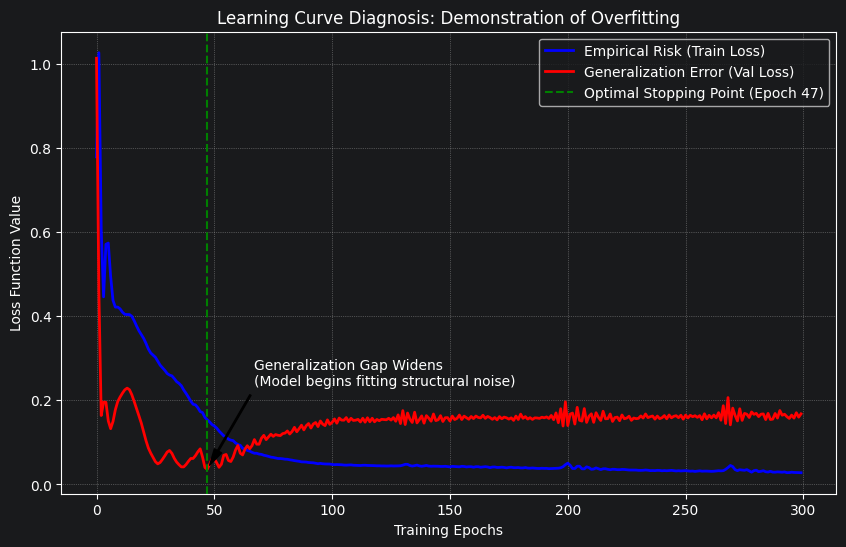

诊断结论：验证集损失函数在 Epoch 47 达到极小值。
越过该阈值后，经验风险持续下降而泛化误差显著攀升，标志着系统已陷入严重的过拟合状态。


In [3]:
import torch.nn as nn
import torch.optim as optim

# 1. 构建病态数据集：极小样本量 + 高频随机噪声
torch.manual_seed(42)
X_train = torch.linspace(-3, 3, 20).view(-1, 1)
y_train = torch.sin(X_train) + 0.5 * torch.randn(X_train.size())

X_val = torch.linspace(-3, 3, 100).view(-1, 1)
y_val = torch.sin(X_val)

# 2. 构建冗余模型：相对当前数据集规模，参数量严重超载
overfit_model = nn.Sequential(
    nn.Linear(1, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
)

optimizer = optim.Adam(overfit_model.parameters(), lr=0.01)
criterion = nn.MSELoss()

train_losses = []
val_losses = []

# 3. 执行过度迭代 (300 Epochs)
for epoch in range(300):
    # 经验风险最小化阶段
    overfit_model.train()
    optimizer.zero_grad()
    pred_train = overfit_model(X_train)
    loss_train = criterion(pred_train, y_train)
    loss_train.backward()
    optimizer.step()

    # 泛化误差评估阶段
    overfit_model.eval()
    with torch.no_grad():
        pred_val = overfit_model(X_val)
        loss_val = criterion(pred_val, y_val)

    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())

# 4. 泛化误差与经验误差对比诊断图
plt.figure(figsize=(10, 6))

plt.plot(train_losses, label='Empirical Risk (Train Loss)', color='blue', linewidth=2)
plt.plot(val_losses, label='Generalization Error (Val Loss)', color='red', linewidth=2)

best_epoch = np.argmin(val_losses)
plt.axvline(best_epoch, color='green', linestyle='--', label=f'Optimal Stopping Point (Epoch {best_epoch})')

plt.title("Learning Curve Diagnosis: Demonstration of Overfitting")
plt.xlabel("Training Epochs")
plt.ylabel("Loss Function Value")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# 标注泛化能力拐点
plt.annotate('Generalization Gap Widens\n(Model begins fitting structural noise)',
             xy=(best_epoch, val_losses[best_epoch]),
             xytext=(best_epoch+20, val_losses[best_epoch]+0.2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.show()

print(f"诊断结论：验证集损失函数在 Epoch {best_epoch} 达到极小值。")
print("越过该阈值后，经验风险持续下降而泛化误差显著攀升，标志着系统已陷入严重的过拟合状态。")

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


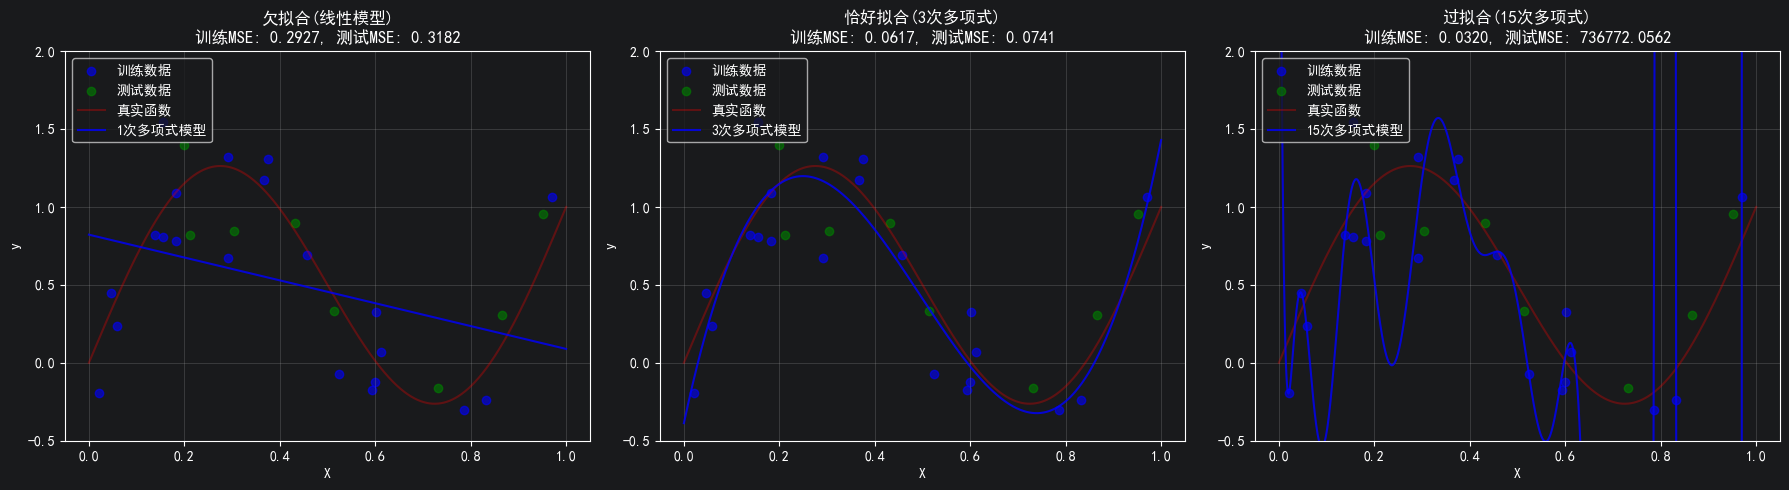

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


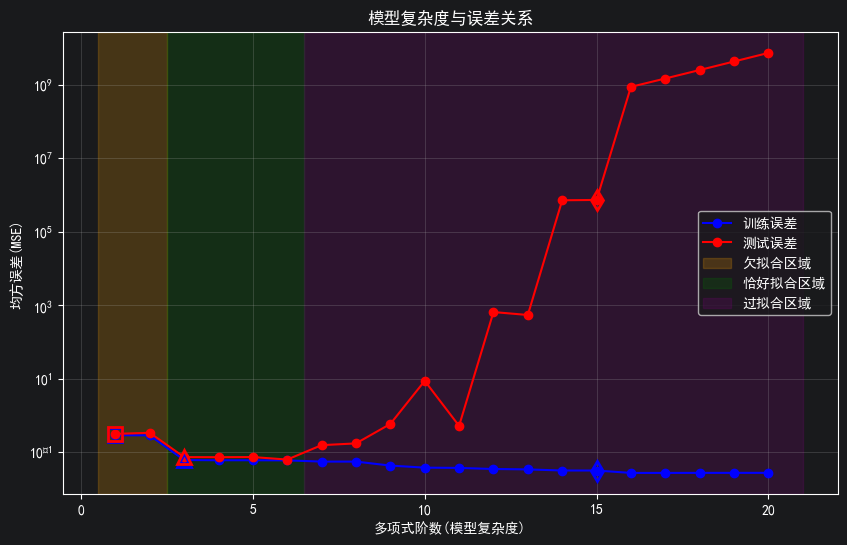

模型性能对比:
UNDERFITTING (1次多项式):
  训练误差: 0.292675
  测试误差: 0.318174
  泛化能力: 差
  偏差-方差权衡: 高偏差, 低方差

GOOD_FIT (3次多项式):
  训练误差: 0.061708
  测试误差: 0.074082
  泛化能力: 好
  偏差-方差权衡: 平衡的偏差和方差

OVERFITTING (15次多项式):
  训练误差: 0.032040
  测试误差: 736772.056213
  泛化能力: 差
  偏差-方差权衡: 低偏差, 高方差



In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 正确显示负号
# 设置随机种子，确保结果可复现
np.random.seed(42)
# 生成一个非线性数据集
def generate_nonlinear_data(n_samples=50, noise=0.5):
    """生成一个带有噪声的非线性数据集"""
    X = np.sort(np.random.uniform(0, 1, n_samples)).reshape(-1, 1)
    # 真实函数: f(x) = sin(2*pi*x) + x
    y_true = np.sin(2 * np.pi * X) + X
    # 添加高斯噪声
    y = y_true + noise * np.random.normal(0, 1, size=X.shape)
    return X, y, y_true
# 生成数据
X, y, y_true = generate_nonlinear_data(n_samples=30, noise=0.3)
# 将数据分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# 创建一个函数来拟合不同复杂度的多项式模型
def fit_polynomial_model(degree, X_train, y_train, X_test, y_test):
    """拟合指定阶数的多项式模型，并返回训练误差和测试误差"""
    # 创建多项式回归模型
    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=True),
        LinearRegression()
    )
    # 在训练集上拟合模型
    model.fit(X_train, y_train)
    # 在训练集和测试集上进行预测
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    # 计算均方误差
    train_error = mean_squared_error(y_train, y_train_pred) #MSE
    test_error = mean_squared_error(y_test, y_test_pred)
    return model, train_error, test_error
# 尝试不同阶数的多项式模型
degrees = [1, 3, 15]  # 分别对应欠拟合、恰好拟合、过拟合
models = []
train_errors = []
test_errors = []
for degree in degrees:
    model, train_error, test_error = fit_polynomial_model(
        degree, X_train, y_train, X_test, y_test
    )
    models.append(model)
    train_errors.append(train_error)
    test_errors.append(test_error)
# 创建对比图
plt.figure(figsize=(18, 5))
# 创建拟合对比子图
titles = ['欠拟合(线性模型)', '恰好拟合(3次多项式)', '过拟合(15次多项式)']
fit_names = ['underfitting', 'good_fit', 'overfitting']
# 创建更密集的点来绘制光滑曲线
X_plot = np.linspace(0, 1, 1000).reshape(-1, 1)
for i, (degree, model, title) in enumerate(zip(degrees, models, titles)):
    plt.subplot(1, 3, i+1)
    # 绘制原始数据点
    plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='训练数据')
    plt.scatter(X_test, y_test, color='green', alpha=0.6, label='测试数据')
    # 绘制真实函数曲线
    plt.plot(X_plot, np.sin(2 * np.pi * X_plot) + X_plot, 'r-', alpha=0.3, label='真实函数')
    # 绘制模型预测曲线
    y_plot = model.predict(X_plot)
    plt.plot(X_plot, y_plot, 'b-', alpha=0.8, label=f'{degree}次多项式模型')
    # 添加误差信息
    train_error = train_errors[i]
    test_error = test_errors[i]
    plt.title(f"{title}\n训练MSE: {train_error:.4f}, 测试MSE: {test_error:.4f}")
    plt.xlabel('X')
    plt.ylabel('y')
    plt.ylim(-0.5, 2.0)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('polynomial_fitting_comparison.png', dpi=300)
# 创建误差曲线图
plt.figure(figsize=(10, 6))
degrees_range = range(1, 21)
train_errors_curve = []
test_errors_curve = []
for degree in degrees_range:
    _, train_error, test_error = fit_polynomial_model(
        degree, X_train, y_train, X_test, y_test
    )
    train_errors_curve.append(train_error)
    test_errors_curve.append(test_error)
plt.plot(degrees_range, train_errors_curve, 'o-', color='blue', label='训练误差')
plt.plot(degrees_range, test_errors_curve, 'o-', color='red', label='测试误差')
# 标记三个关键点
for degree, marker_style in zip([1, 3, 15], ['s', '^', 'd']):
    idx = degree - 1
    plt.plot(degree, train_errors_curve[idx], marker_style, markersize=10,
             markerfacecolor='none', markeredgecolor='blue', markeredgewidth=2)
    plt.plot(degree, test_errors_curve[idx], marker_style, markersize=10,
             markerfacecolor='none', markeredgecolor='red', markeredgewidth=2)
# 添加区域标记
plt.axvspan(0.5, 2.5, alpha=0.2, color='orange', label='欠拟合区域')
plt.axvspan(2.5, 6.5, alpha=0.2, color='green', label='恰好拟合区域')
plt.axvspan(6.5, 21, alpha=0.2, color='purple', label='过拟合区域')
plt.xlabel('多项式阶数(模型复杂度)')
plt.ylabel('均方误差(MSE)')
plt.title('模型复杂度与误差关系')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')  # 使用对数刻度更清晰地显示误差变化
plt.savefig('error_vs_complexity.png', dpi=300)
plt.show()
# 输出结果
print("模型性能对比:")
for i, degree in enumerate(degrees):
    print(f"{fit_names[i].upper()} ({degree}次多项式):")
    print(f"  训练误差: {train_errors[i]:.6f}")
    print(f"  测试误差: {test_errors[i]:.6f}")
    print(f"  泛化能力: {'差' if i != 1 else '好'}")
    print(f"  偏差-方差权衡: {'高偏差, 低方差' if i == 0 else '低偏差, 高方差' if i == 2 else '平衡的偏差和方差'}")
    print()